In [1]:
%%HTML
<script src="require.js"></script>

In [2]:
from IPython.display import HTML, display, Markdown, Image

HTML(
    '<script src="https://cdnjs.cloudflare.com/ajax/libs/jquery/2.0.3/'
    'jquery.min.js"></script>'
    '<script>'
    'code_show=true;'
    'function code_toggle(){'
    'if(code_show){'
    "$('div.jp-CodeCell > div.jp-Cell-inputWrapper').hide();"
    '}else{'
    "$('div.jp-CodeCell > div.jp-Cell-inputWrapper').show();"
    '}'
    'code_show=!code_show;'
    '}'
    '$(document).ready(code_toggle);'
    '</script>'
    '<form action="javascript:code_toggle()">'
    '<input type="submit" value="Click here to toggle on/off the raw code.">'
    '</form>'
)

In [10]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, to_date, lit, mean as _mean, date_format,
    input_file_name, regexp_extract, expr
)
from typing import List, Dict, Tuple
import glob, gzip, re
from functools import reduce
import numpy as np



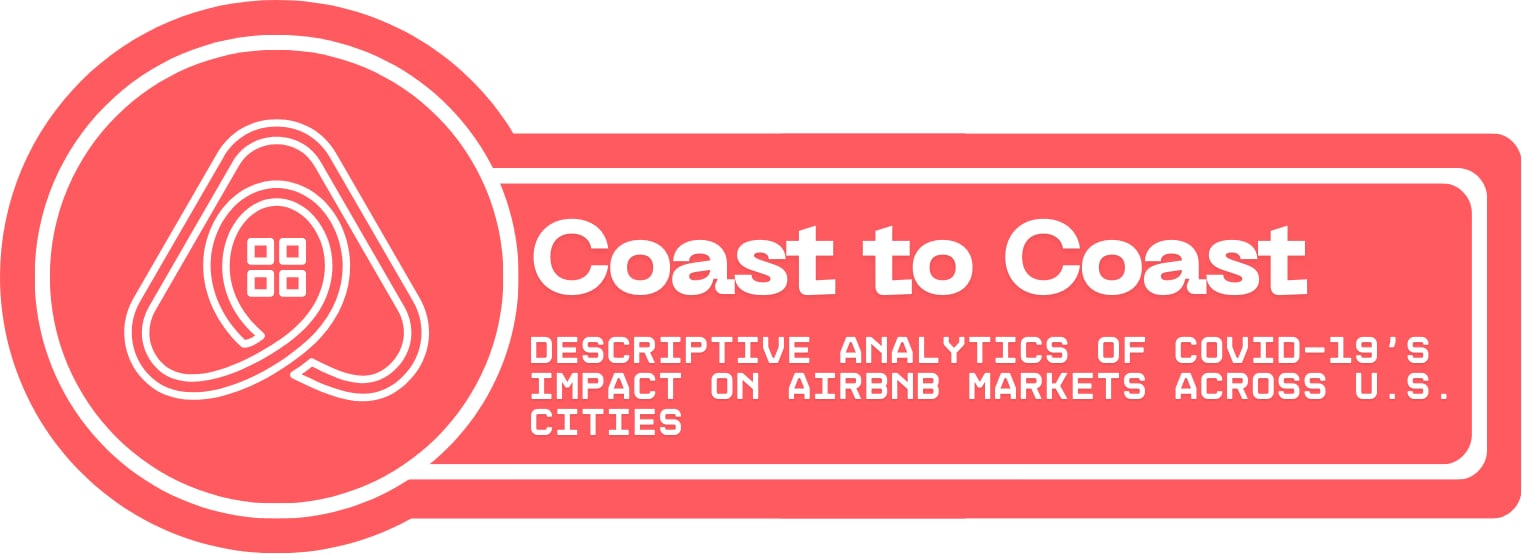

<a id='ExecSum'></a>
<h1 style="color:#ffffff; background-color:#ff5a5f; border: 1px solid #ffffff; padding: 10px 0;">
I. Abstract
</h1>


This study examines the impact of COVID-19 on the Airbnb markets in New York, Los Angeles, and Austin using publicly available data from Inside Airbnb. We will use descriptive analytics on three primary variables in the data: price, calculated host listing, and availability. The time frame will be 2019 to 2021 to understand the analytics before, during, and after the pandemic, but this was also a limiting factor because data before and after the dates were sporadic and did not provide any helpful information. The results of the descriptive analytics showed that Austin experienced the sharpest price decline due to its heavy reliance on event-driven tourism, which underpins its Airbnb market. At the same time, other cities, such as New York and Los Angeles, remained more stable due to their larger populations and diverse economic activity. Graphical trends of multi-property hosting and availability revealed noticeable shifts, spikes, declines, and uneven recovery patterns, highlighting how differently structured markets respond to the global pandemic. This highlights the importance of descriptive data and descriptive analysis in understanding short-term rental dynamics during periods of economic disruption. 


<a id='Introduction'></a>
<h1 style="color:#ffffff; background-color:#ff5a5f; border: 1px solid #ffffff; padding: 10px 0;">II. Introduction</h1>

The Covid-19 Pandemic caused a global collapse in travel and hospitality as international boards began closing and domestic travel was restricted. Studies have shown that the pandemic created significant economic damage to the tourism industry which relied heavily on travel and hospitality (Naveed et al. 2024). In cities such as New York, Los Angeles and Austin Texas this is more relevant than ever. 

Within New York city, a research paper during the pandemic on the city’s tourism found that the city was vulnerable because of its status as a high volume international destination. Because of COVID-19 and the tightening restriction to travel arrivals and mobility led to steep declines in the Economy of hospitality activity (Naveed et al. 2024).
Los Angeles on the other hand depended heavily on tourism because of its connection to the entertainment industry. When the pandemic stopped film production and restricted movement, the local entertainment industry suffered losses with economic analyses showing significant job reductions and revenue declines across LA’s entertainment (Beacon Economics, “The Impact of COVID-19 on Los Angeles’ Entertainment Industry”).

Austin’s economy on the other hand was focused around major gatherings and events. When COVID-19 came into events and large social gatherings were halted. With this Austin experienced sharp drops in visitors and spending. A survey on Austin showed economic stress on the local economy and a decline in tourism (Filieri et al. 2023).

Because Airbnb operates right in the middle of tourism and urban mobility, its data base offers a way to track how the pandemic reshaped the rental markets. Research on Airbnb during COVID-19 shows significant shifts in booking behavior and pricing patterns with many markets experiencing reduced stays and altered consumer preferences(Fox et al. 2023). By analyzing these changes in prices, multi-property host activity, and listing availability before, during, and after the pandemic, this study aims to measure how New York, Los Angeles, and Austin each responded and how their markets recovered.


<a id='Problem Statement'></a>
<h1 style="color:#ffffff; background-color:#ff5a5f; border: 1px solid #ffffff; padding: 10px 0;">III.Problem Statement</h1>

This project aims to study how the COVID-19 crisis influenced key operational indicators in Airbnb markets across New York, Austin, and Los Angeles. Specifically, it evaluates three major impacts:
1. Changes in rent prices over time,
2. Changes in the number of listings controlled by multi-property hosts, and
3. Changes in listing availability throughout the pandemic timeline.

#### The goal is to quantify how the pandemic reshaped host behavior, market supply, and consumer demand across these three major U.S. cities.


<a id='Methodology'></a>
<h1 style="color:#ffffff; background-color:#ff5a5f; border: 1px solid #ffffff; padding: 10px 0;">IV. METHODOLOGY</h1>

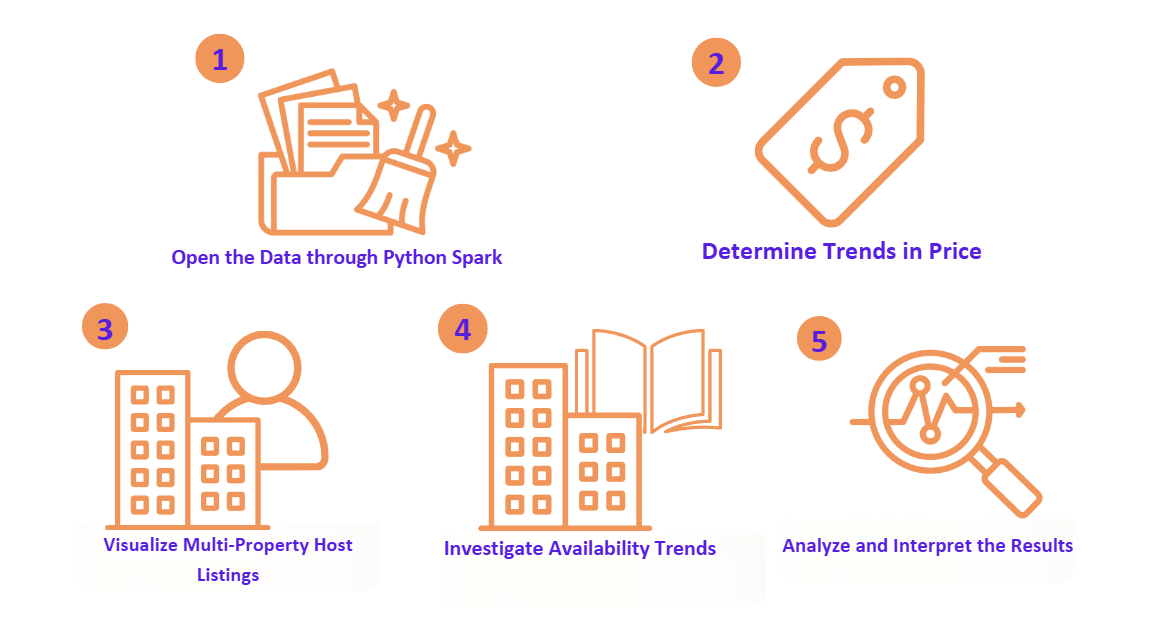

<left><span style="font-size:14px"><b>Figure 1. </b>Methodology</span></left>



3.1 Data Processing and Cleaning

We limited the scope to the specific columns identified during exploration, such as `price`, `calculated_host_listings_count`, and `availability_365`, to keep the dataset focused and manageable. Given the massive size of the InsideAirbnb repository, downloading everything was unnecessary and inefficient. Instead, we extracted only the CSV files containing these variables. We screened the data to contain only records from 2019 to 2021, since this period was most relevant to our analysis and provided sufficient variation to observe market shifts before, during, and after the pandemic. 

- Load all CSV files into Spark DataFrames to handle large file sizes efficiently.
- Exclude unneccessary columns not used for visualization
- Exclude corrupted CSV files that fail to load


3.2 Price Analysis

To see how the price of listings change over time,the `price` of each listing is separated into different csv date files, so the average of each date is calculated and graphed.


3.3 Multi-Property Host Analysis

To see the behavior of multi-property hosts, we can see the number of properties the hosts have, then graph to show how the average `calculated_host_listings_count` change through the years.


3.4 Availability Analysis

To see how listings change whether they are available for renting, we create graphs to track `availability_365` trends.


3.5 Interpret Results

Insights and business recommendations are then made after creating all the descriptive analytics


<a id='Collection'></a>
<h1 style="color:#ffffff; background-color:#ff5a5f; border: 1px solid #ffffff; padding: 10px 0;">IV. Collect and Preprocess the Data</h1>

<h2 style="color:#ff9a00">A. Data Source</h2>

The team utilized the InsideAirBnB dataset, which is publicly available through the ‘jojie-collected’ repository in the /mnt/data/public directory maintained by the Asian institute of Management. The datasets, located at `/mnt/data/public/insideairbnb/data.insideairbnb.com/`included several cities, but for this project we will be focusing on the United States more specifically New York, Los Angeles, and Austin. Their data is spread across multiple CSV files, which are large and separated by dates. Creating cleaned copies for every file would require significant storage, time, and duplicated processing. For this reason, we did not build a separate global preprocessing pipeline or generate new cleaned versions of the raw datasets.

Instead, we applied minimal preprocessing and handled missing data directly inside the visualization stage. When generating line graphs, bar charts, or descriptive summaries, we hard-coded filters to bypass null values, invalid entries, or empty fields. This allowed us to avoid runtime errors without rewriting or duplicating the underlying CSV files.

This approach kept the runtime efficient and avoided unnecessary copies of already-large datasets. However, it also means the dataset was not cleaned in advance, and filtering occurs only at the moment of visualization. As a result, some inconsistent or problematic rows may still exist in the untouched portions of the raw files. Future users should interpret the results with this limitation in mind, as more extensive cleaning could improve data consistency and accuracy in a more production-level analysis.



<h2 style="color:#ff9a00">B. Data Collection and Database Creation</h2>

To gather the listings data, we narrowed the scope to the years `2019`-`2021` and iterated through the file paths

`united-states/ny/new-york-city`

`united-states/tx/austin`

`united-states/ca/los-angeles`

spark = (
    SparkSession.builder
    .appName("AirbnbUnifiedAnalysis")
    .getOrCreate()
)

In [11]:
ROOT_DIR = ""
PATH_PREFIX = "mnt/data/public/insideairbnb/data.insideairbnb.com/"

START_DATE = "2019-01-01"
END_DATE = "2025-12-31"

CITY_CONFIGS = [
    {
        "label": "new-york-city",
        "root_path": f"{PATH_PREFIX}united-states/ny/new-york-city",
        "regex_key":  "united-states/ny/new-york-city"
    },
    {
        "label": "austin",
        "root_path": f"{PATH_PREFIX}united-states/tx/austin",
        "regex_key": "united-states/tx/austin"
    },
    {
        "label": "los-angeles",
        "root_path": f"{PATH_PREFIX}united-states/ca/los-angeles",
        "regex_key": "united-states/ca/los-angeles"
    },
]


<h2 style="color:#ff9a00">C. Data Description</h2>

The following features were used and considered relevant for this report:

Data Source and Features



<table>
  <thead>
    <tr>
      <th>Feature</th>
      <th>Description</th>
      <th>Data Type</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>host_id</td>
      <td>Unique identifier of host</td>
      <td>integer</td>
    </tr>
    <tr>
      <td>price</td>
      <td>daily price in local currency. Note, $ sign may be used despite locale</td>
      <td>currency(integer)</td>
    </tr>
    <tr>
      <td>calculated_host_listings_count</td>
      <td>The number of listings the host has in the current scrape, in the city/region geography.</td>
      <td>integer</td>
    </tr>
    <tr>
      <td>availability_365</td>
      <td>availability_x. The availability of the listing x days in the future as determined by the calendar. Note a listing may be available because it has been booked by a guest or blocked by the host.</td>
      <td>integer</td>
    </tr>
  </tbody>
</table>

Table 1. Dataset: InsideAirBnB (listings.csv) for New York, Austin, and Los Angeles.

<h2 style="color:#ff9a00">D. Preprocess the Data</h2>

We open the compressed csv's using python, extract the target column, date, then convert it to Spark DataFrames. If the csv file is corrupted or unable to be read, it is then skipped

In [12]:
def read_csv_to_spark(spark, filepath, column, date_pattern):
    match = re.search(date_pattern, filepath)
    if not match:
        return None
    file_date = match.group(1)

    try:
        with gzip.open(filepath, "rt", encoding="utf-8", errors="ignore") as f:
            pdf = pd.read_csv(f, usecols=[column], dtype={column: float})
    except:
        try:
            pdf = pd.read_csv(filepath, usecols=[column], dtype={column: float})
        except:
            return None

    if column not in pdf.columns:
        return None

    pdf["date"] = file_date
    return spark.createDataFrame(pdf)


Then for each csv, the daily mean is collected, with null values being ignored in the calculation. After that, since there are csv files that exist in the same month, they are both averaged to find the monthly average over time.

In [13]:
def collect_daily_metric(
    spark: SparkSession,
    city_configs: List[Dict],
    column: str,
    base_dir: str,
    start_date: str,
    end_date: str,
    is_price: bool = False
):
    print(f"\n=== RUNNING DAILY: {column} ===")
    all_results = []
    daily_col = f"{column}_mean"

    for cfg in city_configs:
        label = cfg["label"]
        root = cfg["root_path"]
        regex = cfg["regex_key"]

        print(f"\n--- {label} ---")

        # PRICE uses visualisations/, others use listings.csv.gz
        if is_price:
            files_pattern = f"{base_dir}/{root}/*/visualisations/listings.csv"
            df = spark.read.option("header", True).option("inferSchema", True) \
                .csv(files_pattern) \
                .withColumn("source_file", input_file_name())
            
            date_pattern = rf"/{regex}/(\d{{4}}-\d{{2}}-\d{{2}})/visualisations/listings.csv"

            df = df.withColumn("date", to_date(
                regexp_extract(col("source_file"), date_pattern, 1),
                "yyyy-MM-dd"
            ))
            df = df.dropna(subset=["date", column])
            df = df.withColumn(column, expr(f"try_cast({column} AS DOUBLE)"))
            df = df.filter(col(column) > 0)

        else:
            files = glob.glob(f"{base_dir}/{root}/*/data/listings.csv.gz")
            print(f"Files found: {len(files)}")

            date_pattern = rf"{regex}/(\d{{4}}-\d{{2}}-\d{{2}})"
            dfs = [read_csv_to_spark(spark, fp, column, date_pattern) for fp in files]
            dfs = [x for x in dfs if x is not None]

            if not dfs:
                print("No readable files.")
                continue

            df = reduce(lambda a, b: a.union(b), dfs)
            df = df.withColumn("date", to_date(col("date"), "yyyy-MM-dd"))
            df = df.filter(col(column).isNotNull())

            # column-specific filters
            if "availability" in column:
                df = df.filter((col(column) >= 0) & (col(column) <= 365))
            if "calculated_host_listings_count" in column:
                df = df.filter(col(column) > 0)

        # Date range filter
        df = df.filter((col("date") >= lit(start_date)) & (col("date") <= lit(end_date)))

        # Aggregate
        daily = (
            df.groupBy("date")
              .agg(_mean(column).alias(daily_col))
              .withColumn("city_label", lit(label))
              .withColumn("month", date_format(col("date"), "yyyy-MM"))
              .orderBy("date")
        )

        all_results.append(daily.toPandas())

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)



In [14]:
def aggregate_monthly(spark, daily_df, column):
    if daily_df.empty:
        return pd.DataFrame()

    daily_col = f"{column}_mean"
    month_col = f"{column}_mean_month"

    sdf = spark.createDataFrame(daily_df)

    return (
        sdf.groupBy("city_label", "month")
           .agg(_mean(daily_col).alias(month_col))
           .orderBy("city_label", "month")
           .toPandas()
    )


<a id='Exploration'></a>
<h1 style="color:#ffffff; background-color:#ff5a5f; border: 1px solid #ffffff; padding: 10px 0;">V. Exploratory Data Analysis</h1>

For `host_listing` and `availability`, we create a line graph and bar graph showing the trend monthly and yearly, but for `price` we kept it as monthly.

In [15]:
# --- Plot monthly trend line (Used for all three metrics) ---
def plot_monthly(city_results: List[Tuple[str, pd.DataFrame]], 
                 column: str, 
                 metric_name: str, 
                 y_label: str, 
                 outfile: str):
    plt.figure(figsize=(12, 6))
    
    # Key dates to mark (Using general dates from original notebooks)
    IMPORTANT_DATES = [
        "2020-03-11",  # WHO pandemic declaration (Host Listings notebook)
        "2021-01-01",
    ]
    
    # Remove duplicates and NaT before processing
    unique_dates = pd.to_datetime(list(set(IMPORTANT_DATES)), errors='coerce')
    unique_dates = unique_dates.dropna().sort_values().unique()

    for dt in unique_dates:
        plt.axvline(dt, linestyle="--", linewidth=1, color='red')
        plt.text(dt, plt.ylim()[0], pd.to_datetime(dt).strftime('%Y-%m-%d'), rotation=90, va="bottom", fontsize=8)
    
    col_name = f"{column}_mean_month"
    
    for label, data in city_results:
        if data.empty:
            continue
            
        df = data.copy()
        
        # Check if the column name exists, if not, check for the daily mean name (used in availability)
        current_col_name = col_name
        if current_col_name not in df.columns:
            current_col_name = f"{column}_mean"
            
        if current_col_name not in df.columns:
            print(f"[{label}] Skipping monthly plot: required column '{current_col_name}' not found.")
            continue
            
        # Determine the date column name
        date_col = 'month'
        if date_col not in df.columns:
            # For availability data, the monthly aggregation might happen outside the function, 
            # so we check if the 'date' column contains month info.
            date_col = 'date' 

        df["month_dt"] = pd.to_datetime(df[date_col])
        plt.plot(df["month_dt"], df[current_col_name], marker="o", label=label)
    
    plt.xlabel("Month")
    plt.ylabel(y_label)
    plt.title(f"Monthly Average {metric_name} by City")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outfile, dpi=150)
    plt.show()
    print(f"Saved figure to {outfile}")


# --- Plot yearly mean bars (Used for host listings count and availability) ---
def plot_yearly(city_results: List[Tuple[str, pd.DataFrame]], 
                column: str, 
                metric_name: str, 
                y_label: str, 
                outfile: str):
    """Bar chart of yearly average availability (2019, 2020, 2021)."""
    all_rows = []
    
    # Determine which column to average. For price/host listings, it's the monthly mean.
    # For availability, the data may come in as daily means aggregated to monthly outside this function.
    col_name_monthly = f"{column}_mean_month"
    col_name_daily = f"{column}_mean"
    
    for label, data in city_results:
        if data.empty:
            continue
            
        df = data.copy()
        
        # Choose the correct column name to use for calculating the yearly mean
        if col_name_monthly in df.columns:
            col_to_group = col_name_monthly
        elif col_name_daily in df.columns:
            col_to_group = col_name_daily
        else:
            print(f"[{label}] Skipping yearly plot: required column '{col_name_monthly}' or '{col_name_daily}' not found.")
            continue
            
        # Determine the date column name for year extraction
        date_col = 'month'
        if date_col not in df.columns:
            date_col = 'date'
            
        # Ensure the date column is ready for string slicing or dt accessor
        if pd.api.types.is_datetime64_any_dtype(df[date_col]):
            df["year"] = df[date_col].dt.year.astype(str)
        else:
            df["year"] = df[date_col].astype(str).str.slice(0, 4)
        
        yearly = (
            df.groupby("year")[col_to_group]
            .mean()
            .reindex(["2019", "2020", "2021"])
        )
        all_rows.append((label, yearly))
    
    # Plot
    plt.figure(figsize=(10, 6))
    years = ["2019", "2020", "2021"]
    x = np.arange(len(years))
    bar_width = 0.25
    offset_index = 0
    
    for label, yearly_series in all_rows:
        y_vals = yearly_series.values
        x_positions = x + offset_index * bar_width
        bars = plt.bar(x_positions, y_vals, width=bar_width, label=label)
        
        for bar, value in zip(bars, y_vals):
            if pd.isna(value):
                continue
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{value:.1f}",
                ha="center",
                va="bottom",
                fontsize=9
            )
        offset_index += 1
    
    # Adjust x-ticks to be centered below the group of bars
    plt.xticks(x + bar_width * (len(all_rows) - 1) / 2, years)
    plt.ylabel(y_label)
    plt.title(f"Yearly Average {metric_name} (2019–2021)")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(outfile, dpi=150)
    plt.show()
    print(f"Saved bar chart to {outfile}")

In [17]:
price_results = []
avail_results = []
host_results = []

PRICE_COL = "price"
AV_COL = "availability_365"
HOST_COL = "calculated_host_listings_count"

spark = (
    SparkSession.builder
    .appName("AirbnbUnifiedAnalysis")
    .getOrCreate()
)

# PRICE --------------------
price_daily = collect_daily_metric(
    spark, CITY_CONFIGS, PRICE_COL, ROOT_DIR,
    START_DATE, END_DATE, is_price=True
)

for city in CITY_CONFIGS:
    df = price_daily[price_daily.city_label == city["label"]]
    monthly = aggregate_monthly(spark, df, PRICE_COL)
    price_results.append((city["label"], monthly))

plot_monthly(price_results, PRICE_COL, "Price", "Average Price", "images/monthly_price.png")


# AVAILABILITY -------------
avail_daily = collect_daily_metric(
    spark, CITY_CONFIGS, AV_COL, ROOT_DIR,
    START_DATE, END_DATE
)

for city in CITY_CONFIGS:
    df = avail_daily[avail_daily.city_label == city["label"]]
    avail_results.append((city["label"], df.drop(columns=["city_label"])))

plot_monthly(avail_results, AV_COL, "Availability", "Avg Availability", "images/availability.png")
plot_yearly(avail_results, AV_COL, "Availability", "Avg Availability", "images/availability_yearly.png")


# HOST COUNTS --------------
host_daily = collect_daily_metric(
    spark, CITY_CONFIGS, HOST_COL, ROOT_DIR,
    START_DATE, END_DATE
)

for city in CITY_CONFIGS:
    df = host_daily[host_daily.city_label == city["label"]]
    monthly = aggregate_monthly(spark, df, HOST_COL)
    host_results.append((city["label"], monthly))

plot_monthly(host_results, HOST_COL, "Host Listings", "Host Listings", "images/host_monthly.png")
plot_yearly(host_results, HOST_COL, "Host Listings", "Host Listings", "images/host_yearly.png")

spark.stop()



=== RUNNING DAILY: price ===

--- new-york-city ---


ERROR:root:Exception while sending command.
Traceback (most recent call last):
  File "/usr/local/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/clientserver.py", line 511, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: reentrant call inside <_io.BufferedReader name=50>

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/clientserver.py", line 539, in send_command
    raise Py4JNetworkError(
py4j.protocol.Py4JNetworkError: Error while sending or receiving
ERROR:root:Exception while sending command.
Traceback (most recent call last):
  File "/usr/local/spark/python/lib/py4j-0.10.9.7-src.zip

Py4JError: An error occurred while calling o27.csv

<a id='Apply FIM'></a>
<h1 style="color:#ffffff; background-color:#ff5a5f; border: 1px solid #ffffff; padding: 10px 0;">VII. Compare, Analyze, and Interpret the Results</h1>

In Figure 2, there are two lines with marked dates; these are the transition points from pre to during and from during to post. As shown in Figure 2, prices in Austin, Texas, have declined sharply. This can be attributed to the city's heavy dependence on large gatherings and event-driven tourism. As noted, the foundation of Austin's local economy is festivals, conventions, and live entertainment, all of which were halted during the COVID-19 pandemic. With these events gone, so did the majority of Austin's visitor traffic, which forced hosts to cut prices dramatically to attract the few remaining renters, resulting in the steep drop shown in the graph.

In contrast, New York City and Los Angeles did not experience this price drop because of their short-term rental markets. Despite significant declines in tourism, both cities have large resident populations and continued local mobility, maintaining a baseline level of occupancy even during the pandemic. As noted in the report's introduction, New York maintained activity due to internal relocations and the presence of essential workers (AirDNA, 2021), while Los Angeles was cushioned by its large domestic population and diverse economic base (LACC Annual Report FY 2020–2021). This helped both cities stabilize prices, whereas Austin, which has no comparable local fallback demand, experienced the most severe pricing shock.


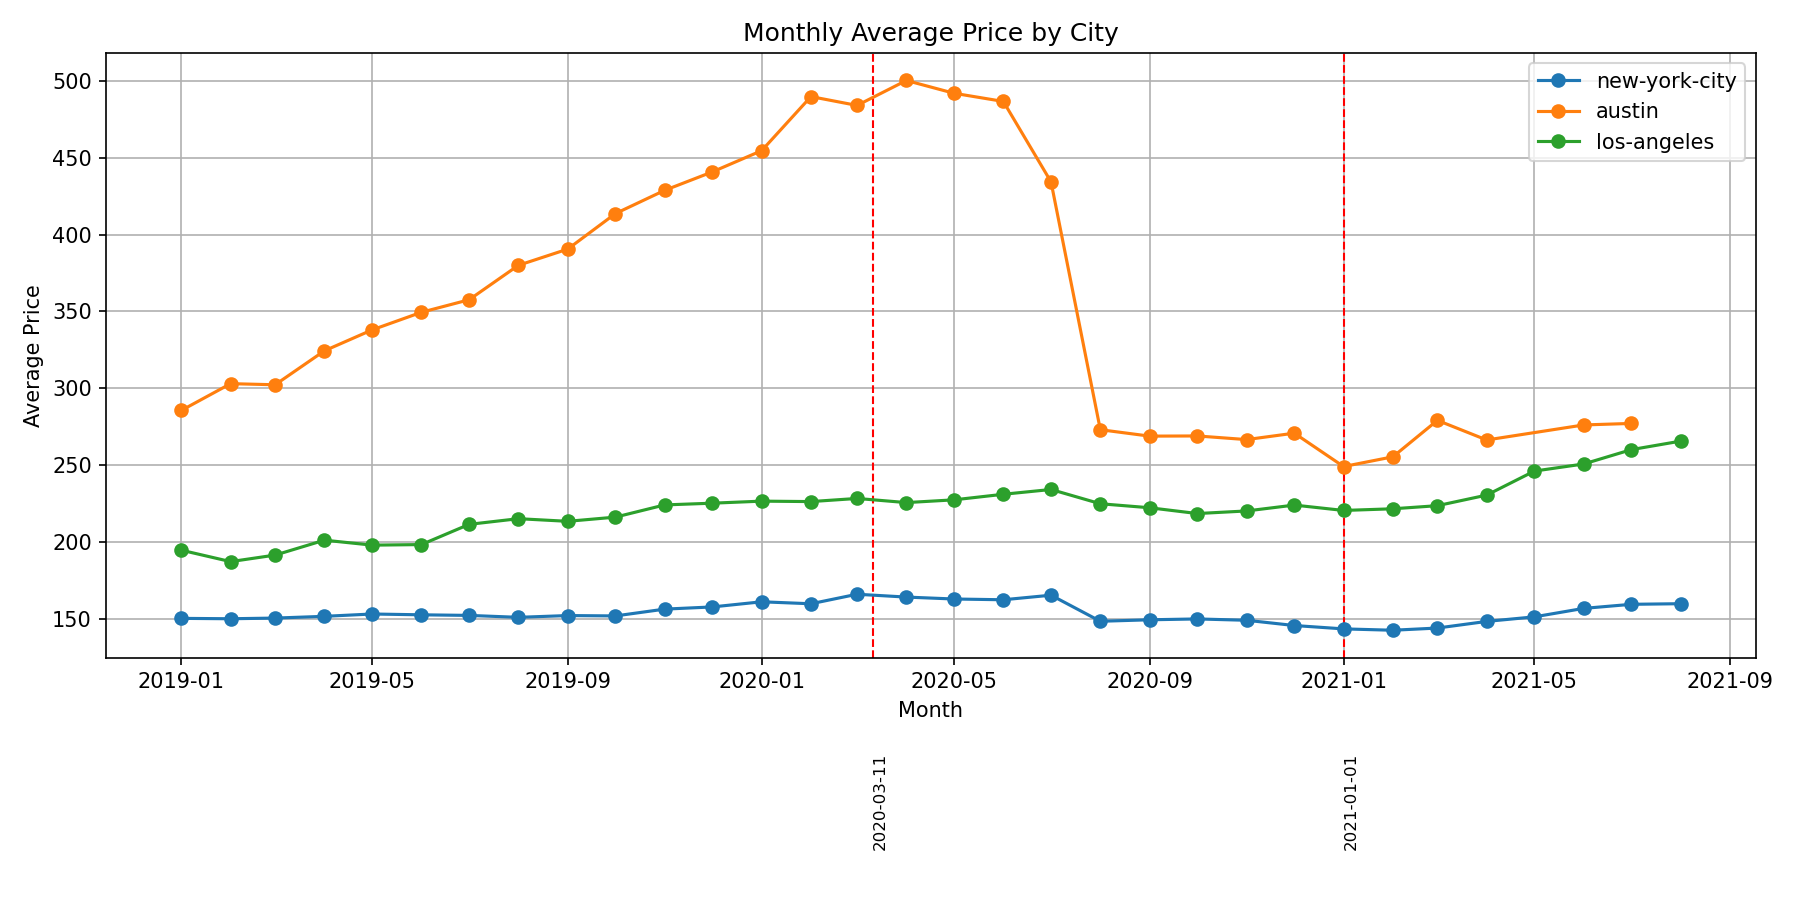

<left><span style="font-size:14px"><b>Figure 2. </b>Monthly Average Price</span></left>

In Figure 3, New York City and Los Angeles follow a relatively flat, smooth upward trend with only minor dips during COVID-19. Figure 3 also suggests that the host listings within the city are much more professional and remain active despite the shock. As for Austing, however, the monthly line shows an extreme spike, jumping to 45 listings per house before quickly collapsing. The spike suggests a consolidation shock: many smaller hosts exit, leaving a gap, while larger, more professional operators hold most of the inventory, inflating the average (AirDNA – COVID-19 STR Supply Report 2021). 

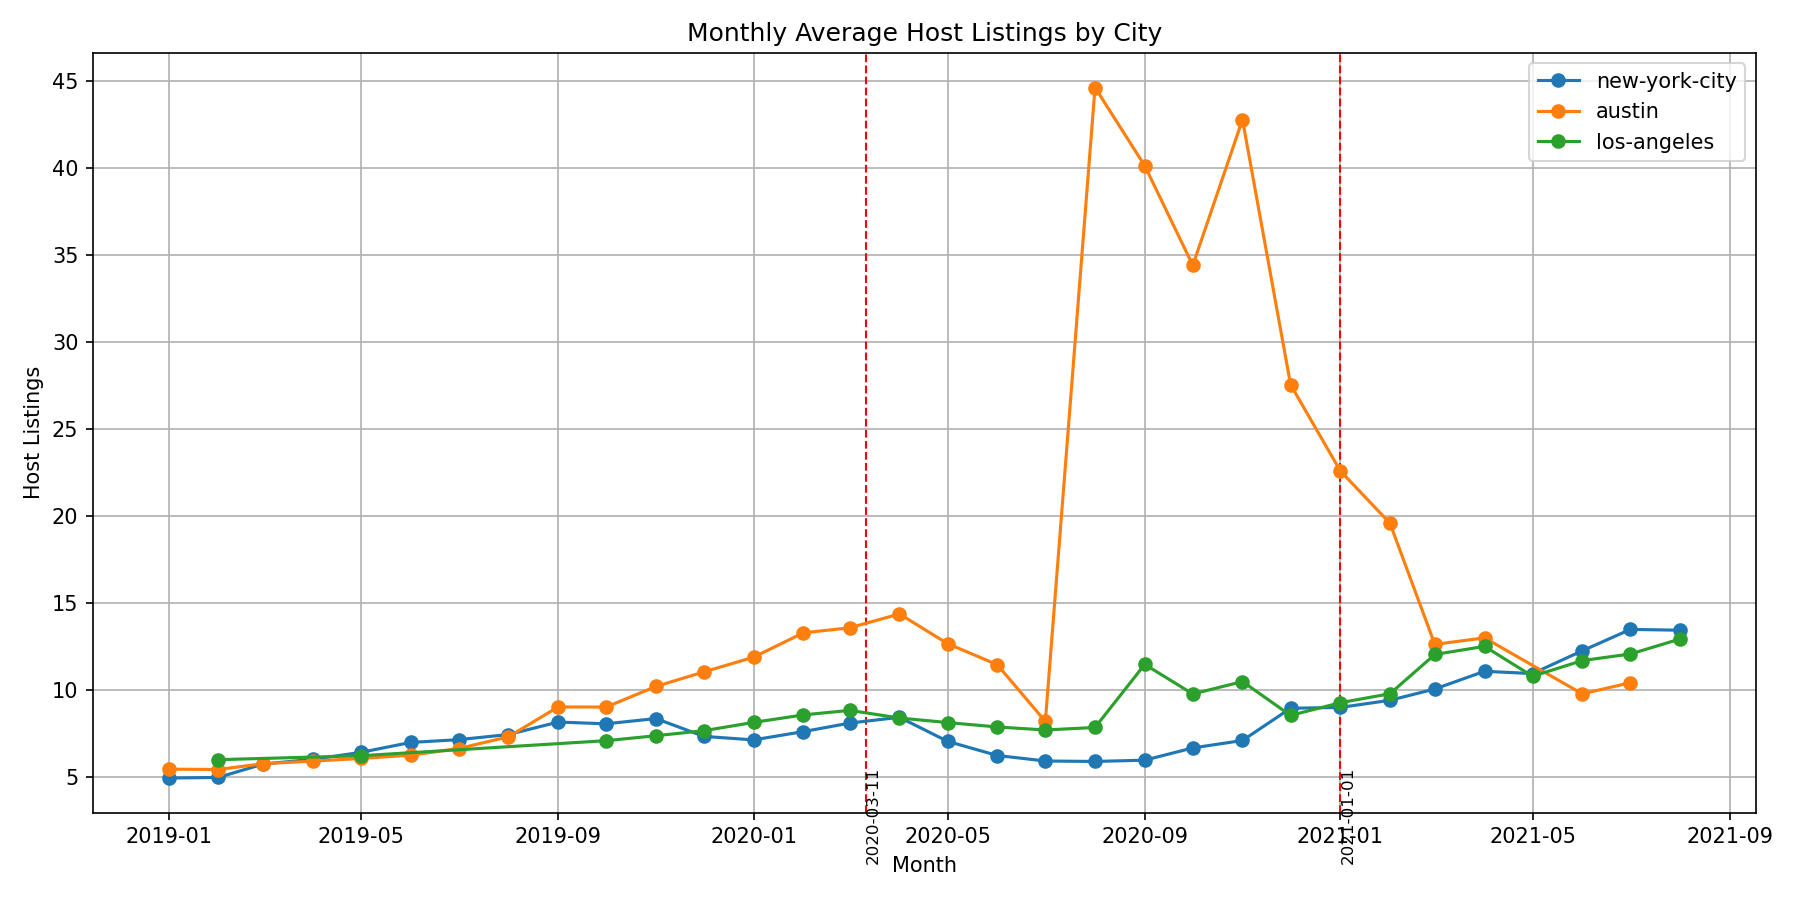

<left><span style="font-size:14px"><b>Figure 3. </b>Monthly Average Number of listings owned</span></left>

Figure 4 translates this Monthly movement into yearly averages and confirms how abnormal Austin's Shock was during COVID-19. While major cities such as New York and Los Angeles gradually increase their host listings, Austin Spikes in its yearly average before falling back to a more respectable range. Spikes such as this show how Austin's tourism and event-driven economy suffered a sharper collapse than the more diversified urban markets of New York and Los Angeles.


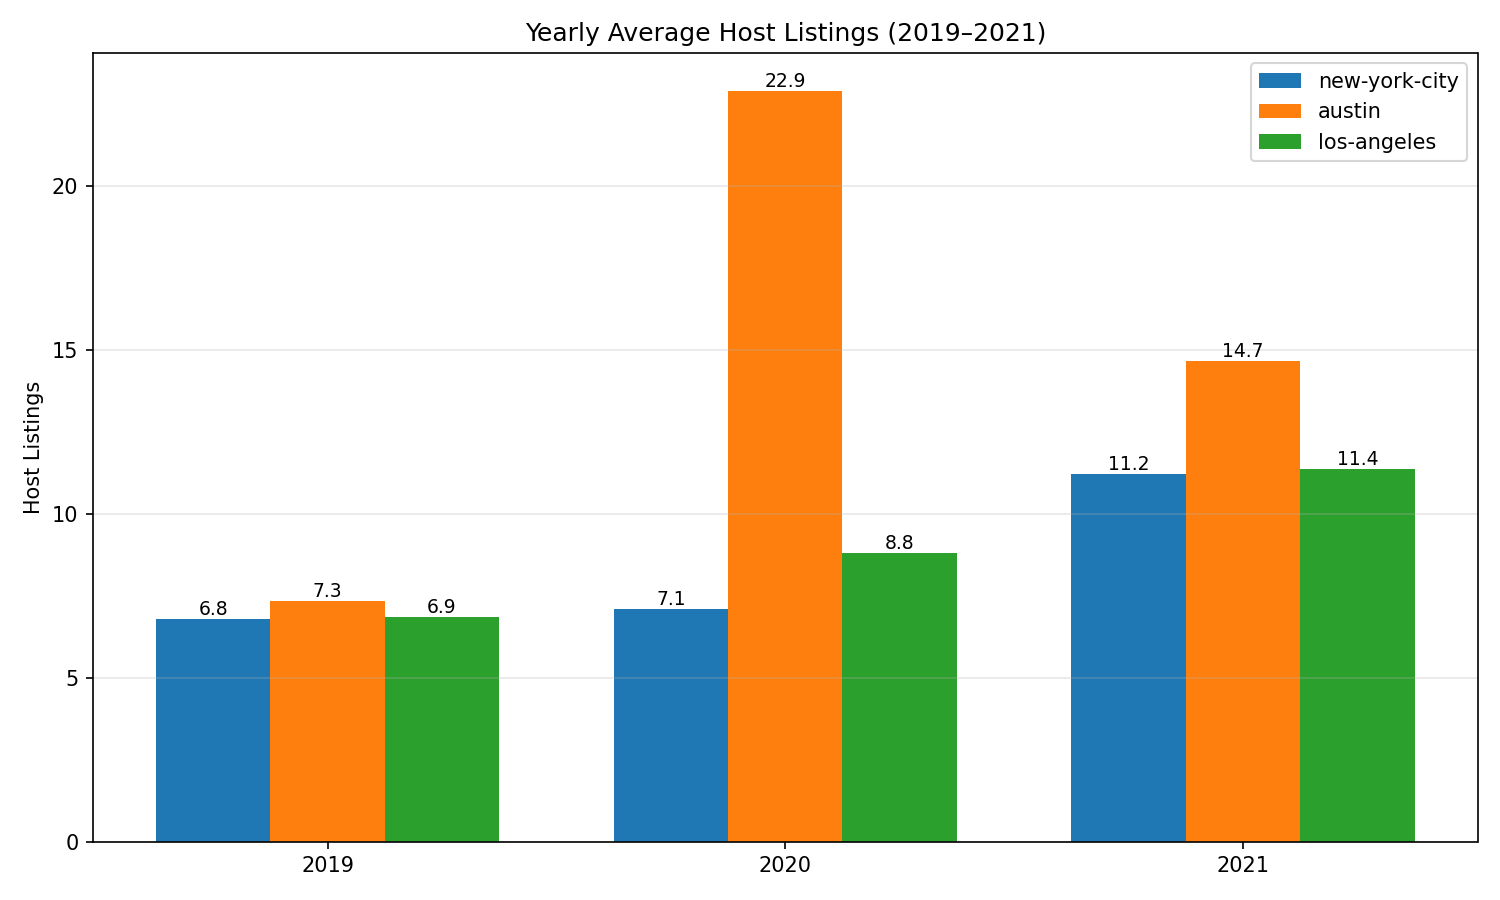

<left><span style="font-size:14px"><b>Figure 4. </b>Yearly Average # of listings owned</span></left>

In Figure 5, availability differs across the three cities, with Los Angeles maintaining the highest availability throughout the three years, indicating a surplus even before the pandemic. On the other hand, New York and Austin moved more moderately. However, there was notable variation during the pandemic: New York gradually increased near the end, while Austin dipped afterward. This Dip for New York and Austin reflects the pressure on hosts to capture what little rental demand exists, leading to shorter availability windows as multi-property hosts try to maintain occupancy (AirDNA, 2021).



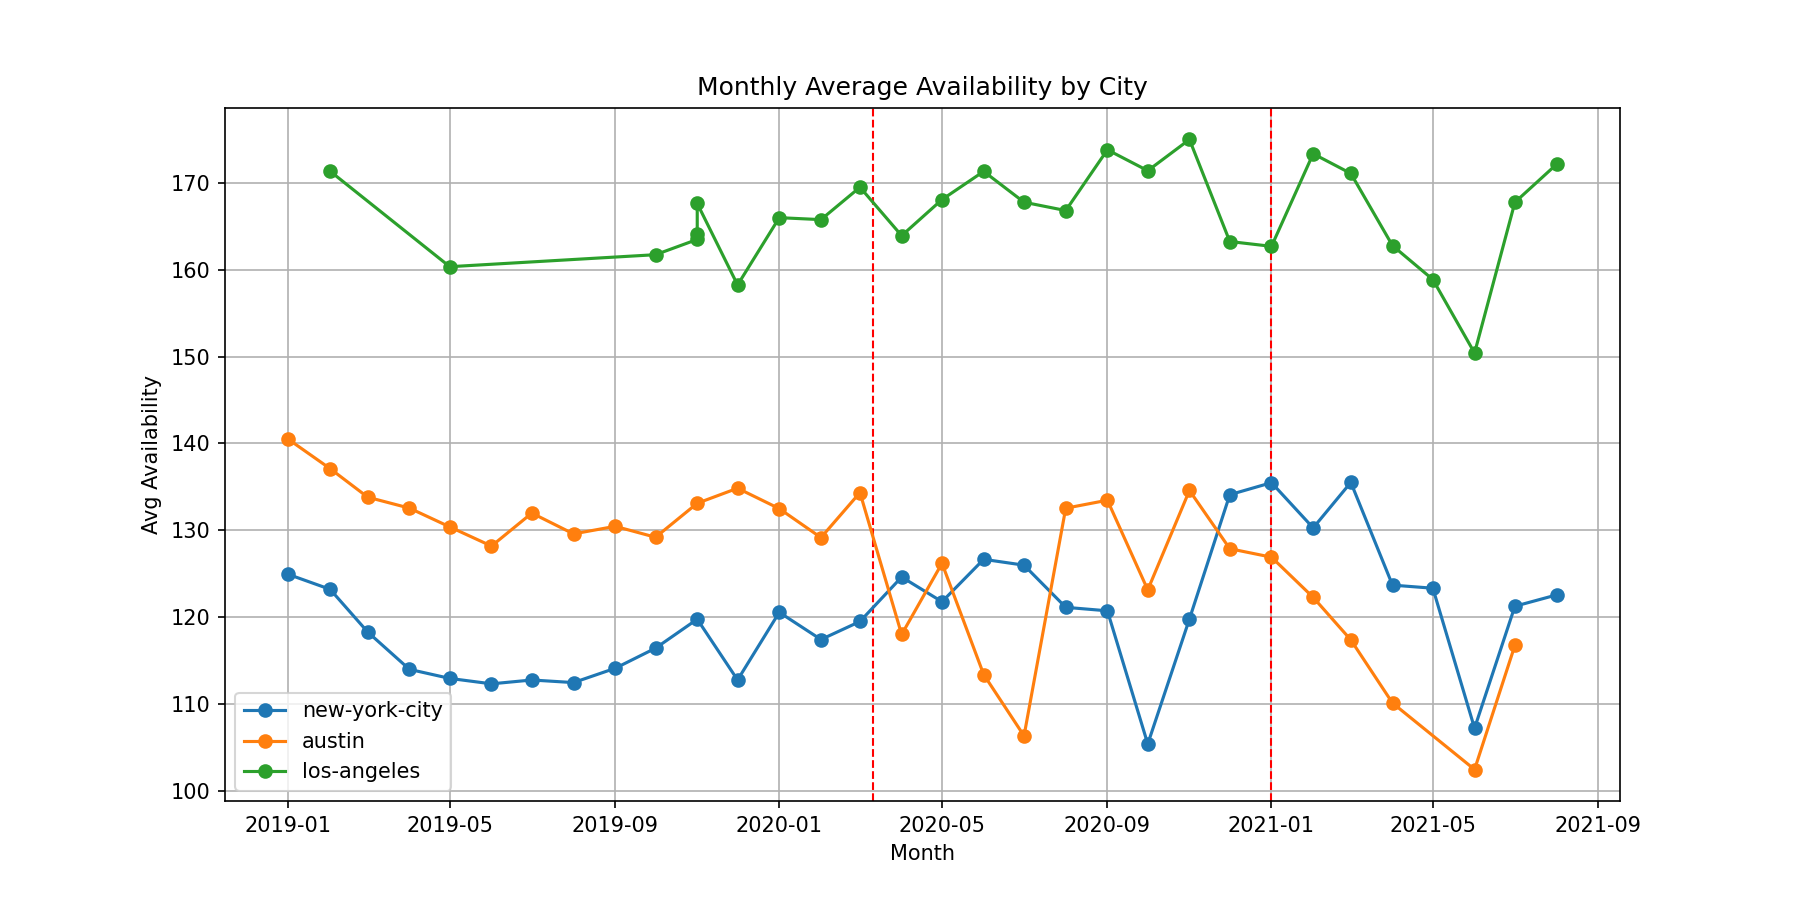

<left><span style="font-size:14px"><b>Figure 5. </b>Monthly Average availability of listings</span></left>

Figure 6 summarizes this fluctuation at the yearly level and confirms the broad pattern observed in Figure 4, with availability crises slightly higher for both New York and Los Angeles, consistent with reduced travel and lower occupancy during the pandemic. In contrast, Austin moves in the opposite direction, with its average falling during the pandemic, showing that supply tightness even as demand collapses. This counter pattern reinforces the earlier interpretation that Austin's Airbnb market is unstable (AirDNA, 2021). Post-pandemic availability levels are beginning to normalize across cities, with Austin's recovery remaining inconsistent.


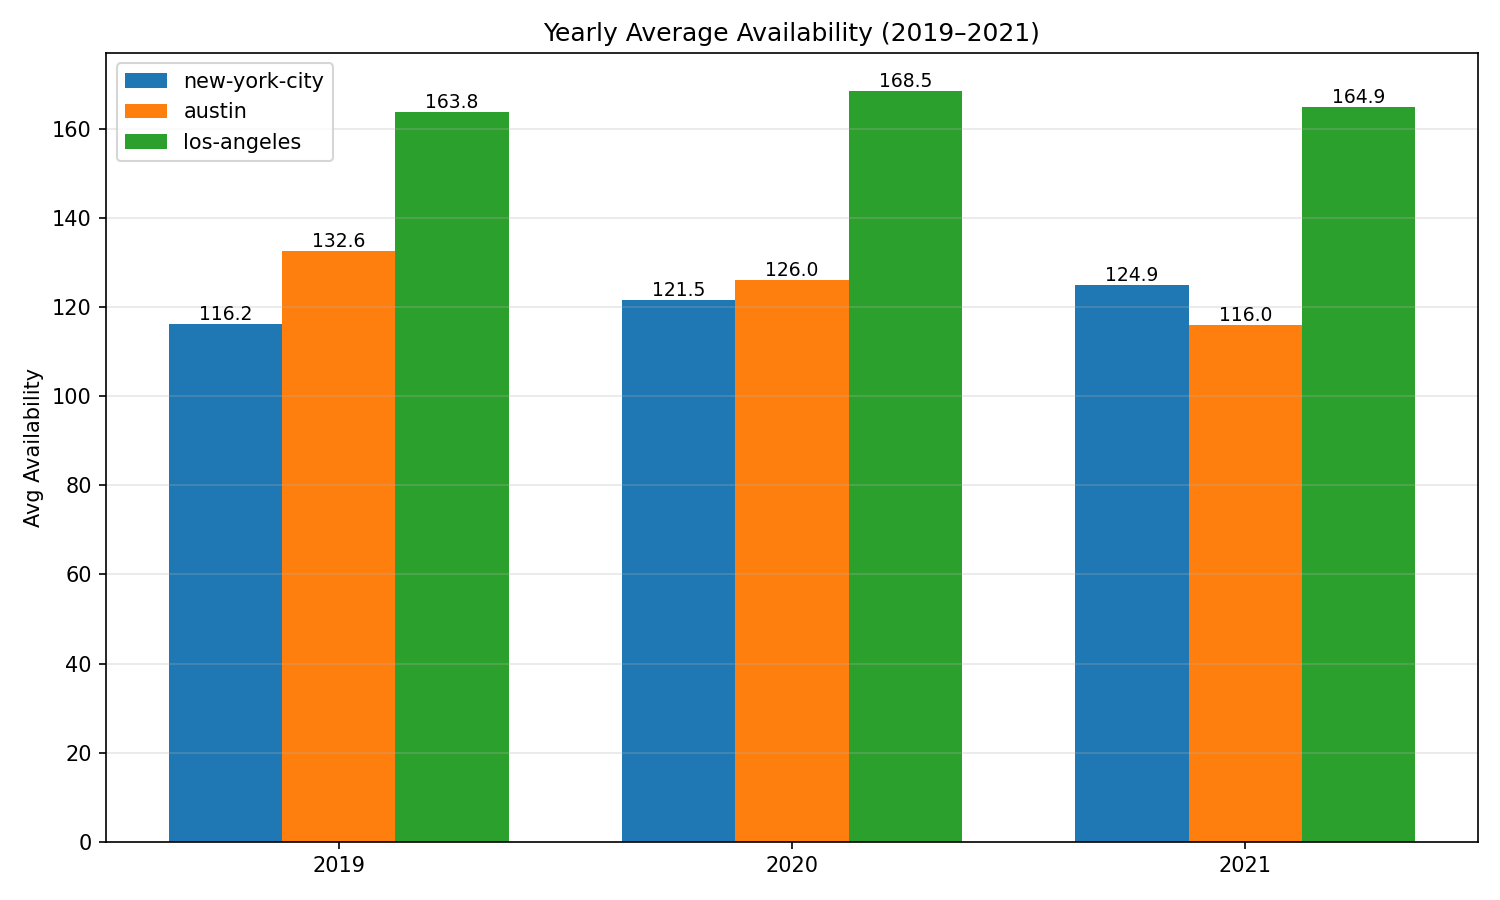

<left><span style="font-size:14px"><b>Figure 5. </b>Yearly Average availability of listings</span></left>

<a id='Recommendation'></a>
<h1 style="color:#ffffff; background-color:#ff5a5f; border: 1px solid #ffffff; padding: 10px 0;">VIII. RECOMMENDATION & LIMITATIONS</h1>

<a id='Limitations'></a>
<h2 style="color:#ff9a00">A. Limitation and Recommendation of the Study</h2>

Within this study, several limitations were identified, and future analysts are encouraged to address them to improve the quality of similar research.

The first recommendation is to incorporate additional listing variables. The variable calculated_host_listings was introduced only in 2019, limiting the study's range. Adding more variables, such as room type, minimum nights, and property type, could improve the analysis. 

The second recommendation is to broaden the coverage of the cities. This project focused on two major cities and one minor one: New York, Los Angeles, and Austin, respectively. Nevertheless, future analyses could include cities such as Chicago, Boston, Seattle, or Miami. Adding more cities can create a stronger comparison of how different markets reacted during the pandemic.

These recommendations aim to support future analysts in building on this study while maintaining methodological consistency and adapting to the structural constraints of the InsideAirbnb dataset.


<a id='Conclusion'></a>
<h1 style="color:#ffffff; background-color:#ff5a5f; border: 1px solid #ffffff; padding: 10px 0;">IX. CONCLUSION</h1>

In conclusion, Austin experienced the sharpest price declines compared to New York and Los Angeles because of its dependence on event driven tourism, while New York and Los Angeles maintained better price stability due to larger populations and a more diversified economy. The analysis of multi property host behavior and availability also showed clear shifts during the pandemic, including spikes, declines, and recovery patterns across cities.

We used descriptive statistics to analyse trends on the InsideAirbnb dataset that was limited by factors such as data completeness, variable availability, and the large size of the dataset. Despite the constraints, the findings found how short term rental markets behaved before, during, and immediately after the height of the pandemic.

Overall, this research highlighted the importance of data driven monitoring of short term rental markets, especially during periods of economic disruption. While the scope of the study was limited, the results offer a foundation for future descriptive research and show how cities with different economic structures respond to major shocks. The recommendations provided aim to guide future analysts in expanding this work while maintaining consistency and adapting to the characteristics of the InsideAirbnb dataset.


<a id='References'></a>
<h1 style="color:#ffffff; background-color:#ff5a5f; border: 1px solid #ffffff; padding: 10px 0;">ACKNOWLEDGEMENTS</h1>

The team would like to acknowledge InsideAirBnB as the original source of the data and the Asian Institute of Management's "jojie-collected" repository for compiling and sharing the insideairbnb dataset for public educational use. They would like to express their sincere appreciation to Professor Christian M. Alis for their invaluable guidance and support in completing this report. The group also acknowledges their use of Artificial Intelligence, such as ChatGPT and Gemini. 

<a id='References'></a>
<h1 style="color:#ffffff; background-color:#ff5a5f; border: 1px solid #ffffff; padding: 10px 0;">REFERENCES</h1>

<ul style="list-style-type:none; padding-left:0;">
  <li style="margin-bottom:1em; text-indent:-1.5em; padding-left:1.5em;">
    Adler, P., Fowler, A., & Bou Zeineddine, M. (2021, May 3). The impact of COVID-19 on Los Angeles’ entertainment industry. (Beacon Economics)<br>
    Retrieved November 21, 2025, from <a href="https://beaconecon.com/the-impact-of-covid-19-on-los-angeles-entertainment-industry">https://beaconecon.com/the-impact-of-covid-19-on-los-angeles-entertainment-industry</a>
  </li>

  <li style="margin-bottom:1em; text-indent:-1.5em; padding-left:1.5em;">
    AirDNA. (n.d.). COVID-19 data center.<br>
    Retrieved November 21, 2025, from <a href="https://www.airdna.co/covid-19-data-center">https://www.airdna.co/covid-19-data-center</a>
  </li>

  <li style="margin-bottom:1em; text-indent:-1.5em; padding-left:1.5em;">
    Jarrett, M., Garrick, R., Gaeta, A., Lombardi, D., Mayo, R., McNulty, P., & Krahn, W. D. (2022). Pandemic preparedness: COVID-19 lessons learned in New York’s hospitals. The Joint Commission Journal on Quality and Patient Safety, 48(9), 475–491.<br>
    Retrieved November 21, 2025, from <a href="https://pmc.ncbi.nlm.nih.gov/articles/PMC9186533/">https://pmc.ncbi.nlm.nih.gov/articles/PMC9186533/</a>
  </li>

  <li style="margin-bottom:1em; text-indent:-1.5em; padding-left:1.5em;">
    Los Angeles Convention Center. (2021). Annual report FY 2020-2021. <br>
    Retrieved November 21, 2025, from <a href="https://www.laconventioncenter.com/assets/doc/LACC-Annual-Report-FY-2020-2021-3a1b74b298.pdf">https://www.laconventioncenter.com/assets/doc/LACC-Annual-Report-FY-2020-2021-3a1b74b298.pdf</a>
  </li>

  <li style="margin-bottom:1em; text-indent:-1.5em; padding-left:1.5em;">
    Naveed, N., & colleagues. (2024) The global impact of COVID-19: A comprehensive analysis of social, health, economic and environmental aspects.<br>
    Retrieved November 21, 2025, from <a href="https://pmc.ncbi.nlm.nih.gov/articles/PMC10964844/">https://pmc.ncbi.nlm.nih.gov/articles/PMC10964844/</a>
  </li>

  <li style="margin-bottom:1em; text-indent:-1.5em; padding-left:1.5em;">
    Taulli, T. (2020, November 21). How Airbnb beat the COVID-19 virus. Forbes. <br>
    Retrieved November 21, 2025, from <a href="https://pmc.ncbi.nlm.nih.gov/articles/PMC10964844/">https://pmc.ncbi.nlm.nih.gov/articles/PMC10964844/</a>
  </li>

</ul>


***
**END**